In [1]:
words = open('names.txt').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [20]:
b = {}

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [26]:
sorted(b.items(), key = lambda kv : -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [27]:
import torch

In [40]:
N = torch.zeros((28,28), dtype = torch.int32)

In [56]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['<S>'] = 0
stoi['<E>'] = 27

In [57]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '<S>': 0,
 '<E>': 27}

In [58]:
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N [ix1, ix2] += 1

In [59]:
N

tensor([[ 556, 4951, 1776, 2584, 2382, 1665,  585, 3001, 2524,  766, 2990, 5491,
         3206, 7976, 1209,  476,  575, 3356, 2757, 2742, 1689,  912,  537,  489,
         2184,  970,  929, 6640],
        [ 321,  594,  542,  535, 1697,  692,  134,  209, 2549, 1651,  175,  671,
         2528, 1638, 5543,   63,   82,  902, 3272, 1120,  732,  381,  834,  161,
          265, 2050,  435, 6754],
        [ 815,  321,   80,    2,  616,  655,    2,  664,  312,  220,  317,  116,
          103,    0,  384,  106,   11,   76,  847,   43,   37,   45,    0,    3,
          104,   87,    0,  211],
        [1303,  816,    3,  191, 1284,  556,   25,  120, 1338,  280,    6,  376,
          146,   31,  378,  380,    2,  435,  105,    9,  127,   52,   23,    0,
          320,  105,    4,  613],
        [ 679, 1424,  154,  387, 1420, 1365,  130,  177,  936,  729,  187, 3251,
          829, 2705,  300,  461,   14, 1959, 1285,  609,   73,  555,   67,  155,
         1070,  498,    1, 4499],
        [ 242,  679,

In [60]:
itos = {i:s for s,i in stoi.items()}

TypeError: unsupported operand type(s) for -: 'str' and 'int'

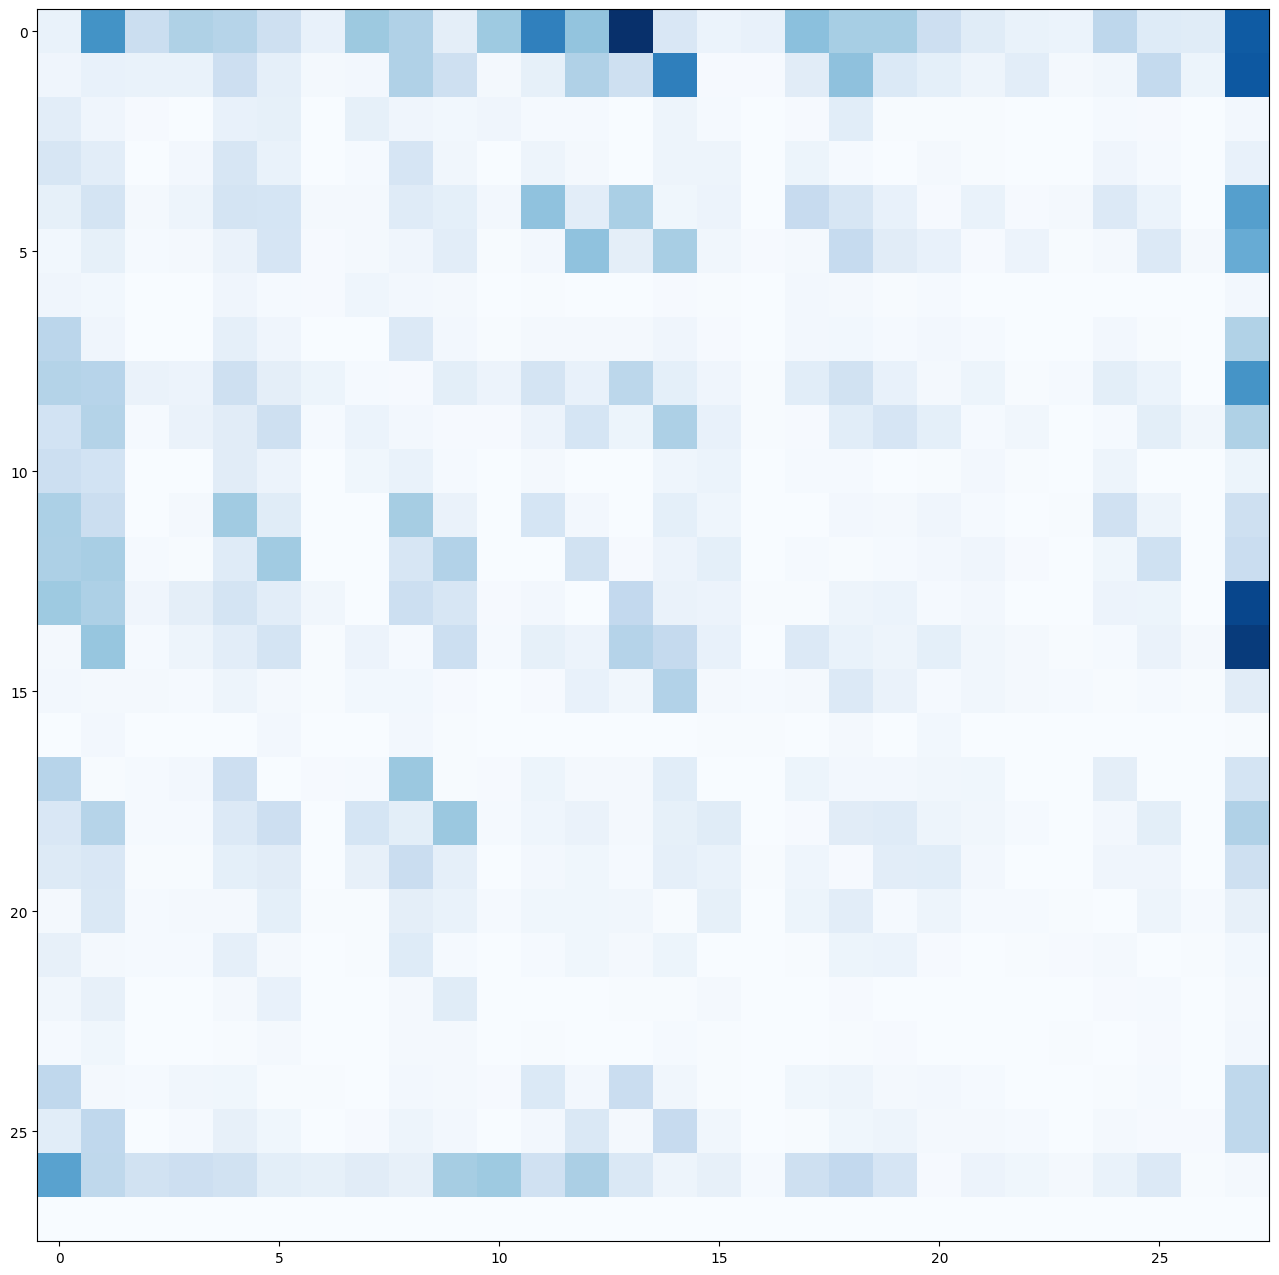

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i,j].item(), ha='center', va='top', color='gray')
plt.axis('off')